In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm

insurance = pd.read_csv("../datasets/insurance.csv")
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
X = insurance.drop(columns=['charges'])
X = pd.get_dummies(X, drop_first=True).astype(float)
y = insurance['charges']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:33:43   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

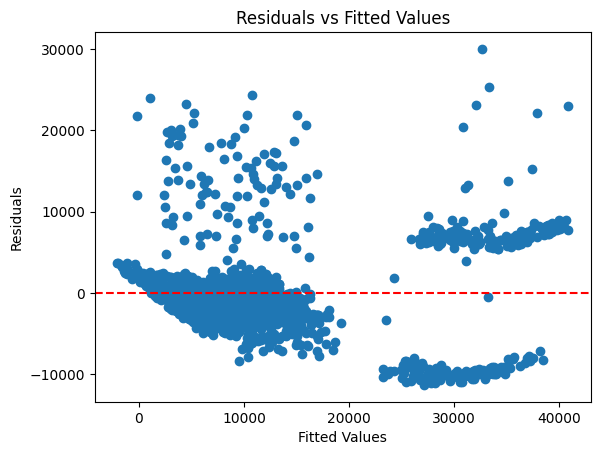

In [5]:
# plot residuals vs fitted values
fitted_values = model.fittedvalues
residuals = model.resid
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

In [10]:
X = insurance.drop(columns=['charges'])
y = insurance['charges']
X = pd.get_dummies(X, drop_first=True).astype(float)
X['age_squared'] = X['age'] ** 2
X['bmi_obese'] = (X['bmi'] >= 30).astype(float)
X['obese_smoker'] = X['bmi_obese'] * X['smoker_yes']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     781.7
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:54:49   Log-Likelihood:                -13131.
No. Observations:                1338   AIC:                         2.629e+04
Df Residuals:                    1326   BIC:                         2.635e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              134.2509   1362.751  

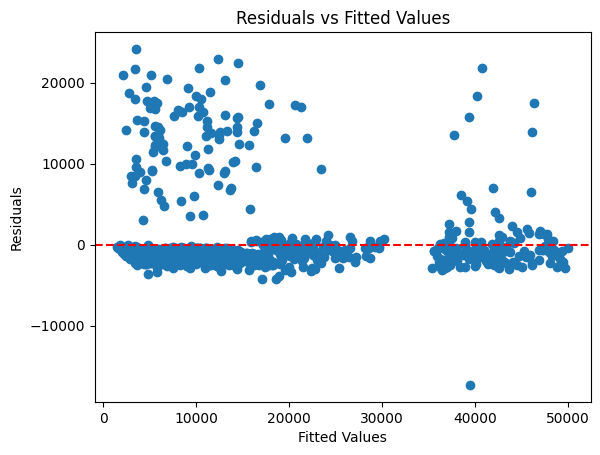

In [11]:
fitted_values = model.fittedvalues
residuals = model.resid
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

In [12]:
y_log = np.log(y)

log_model = sm.OLS(y_log, X).fit()
print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     454.2
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:54:57   Log-Likelihood:                -740.92
No. Observations:                1338   AIC:                             1506.
Df Residuals:                    1326   BIC:                             1568.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.9385      0.130  

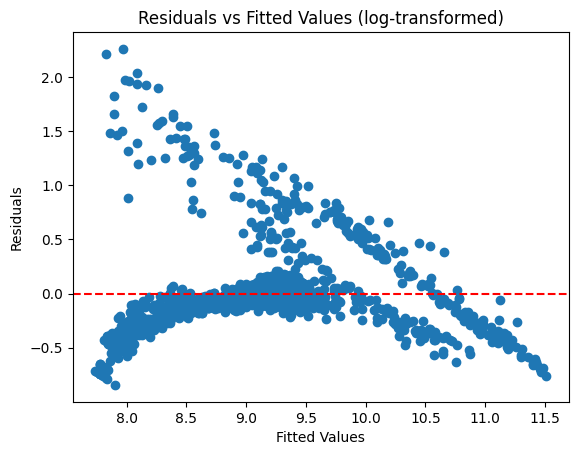

In [13]:
fitted_values = log_model.fittedvalues
residuals = log_model.resid
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values (log-transformed)')
plt.show()

In [14]:
X = insurance.drop(columns=['charges'])
y = insurance['charges']
X = pd.get_dummies(X, drop_first=True).astype(float)
X['age_squared'] = X['age'] ** 2
X['bmi_obese'] = (X['bmi'] >= 30).astype(float)
X['obese_smoker'] = X['bmi_obese'] * X['smoker_yes']
X['bmi_smoker'] = X['bmi'] * X['smoker_yes']
X = sm.add_constant(X)
log_y = np.log(y)
log_model_new = sm.OLS(log_y, X).fit()
print(log_model_new.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     417.1
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:57:08   Log-Likelihood:                -739.48
No. Observations:                1338   AIC:                             1505.
Df Residuals:                    1325   BIC:                             1573.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                7.0065      0.136  

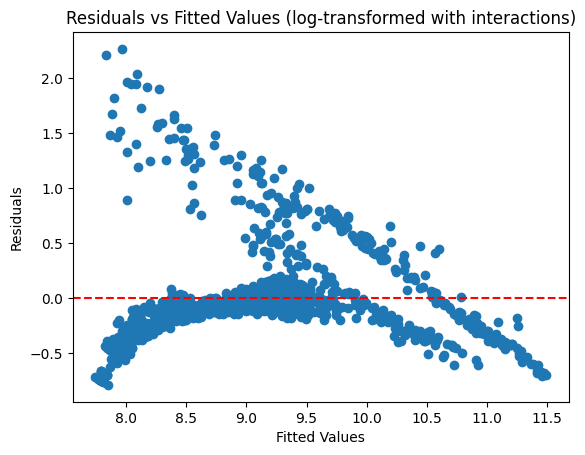

In [15]:
# plot residuals vs fitted values for new log model
fitted_values = log_model_new.fittedvalues
residuals = log_model_new.resid
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values (log-transformed with interactions)')
plt.show()

In [2]:
X = insurance.drop(columns=['charges'])
y = insurance['charges']
X = pd.get_dummies(X, drop_first=True).astype(float)
X['age_squared'] = X['age'] ** 2
X['bmi_obese'] = (X['bmi'] >= 30).astype(float)
X['obese_smoker'] = X['bmi_obese'] * X['smoker_yes']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     781.7
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:09:24   Log-Likelihood:                -13131.
No. Observations:                1338   AIC:                         2.629e+04
Df Residuals:                    1326   BIC:                         2.635e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              134.2509   1362.751  

In [3]:
threshold = y.median()
y_binary = (y > threshold).astype(int)

logit_model = sm.GLM(y_binary, X, family=sm.families.Binomial()).fit()
print(logit_model.summary())

print(np.exp(logit_model.params))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                charges   No. Observations:                 1338
Model:                            GLM   Df Residuals:                     1326
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -287.73
Date:                Wed, 04 Mar 2026   Deviance:                       575.46
Time:                        21:09:28   Pearson chi2:                 1.46e+03
No. Iterations:                    25   Pseudo R-squ. (CS):             0.6157
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                7.8018      1.395  

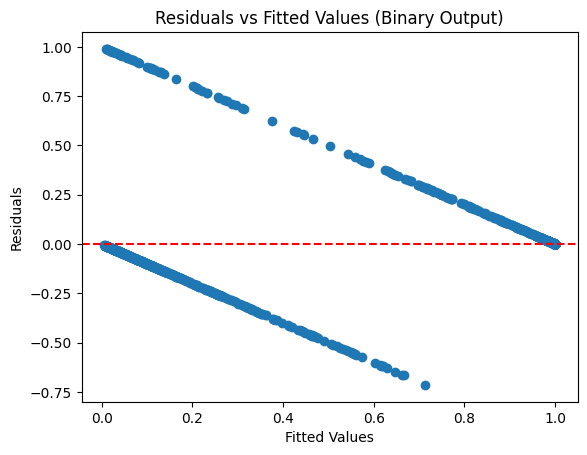

In [6]:
# plot residuals vs fitted values for logistic regression
fitted_values = logit_model.fittedvalues
residuals = y_binary - fitted_values
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values (Binary Output)')
plt.show()

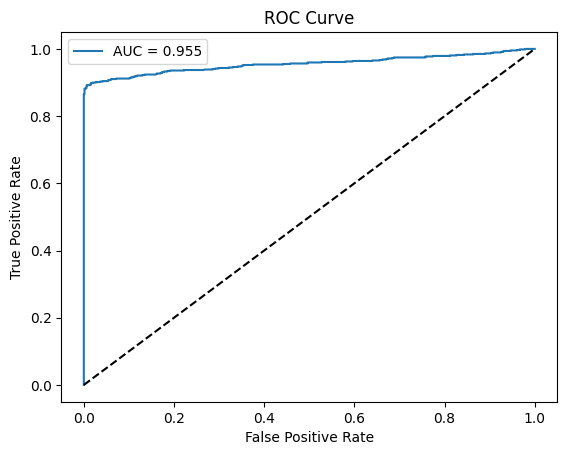

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_prob = logit_model.predict(X)

fpr, tpr, _ = roc_curve(y_binary, y_pred_prob)
auc = roc_auc_score(y_binary, y_pred_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

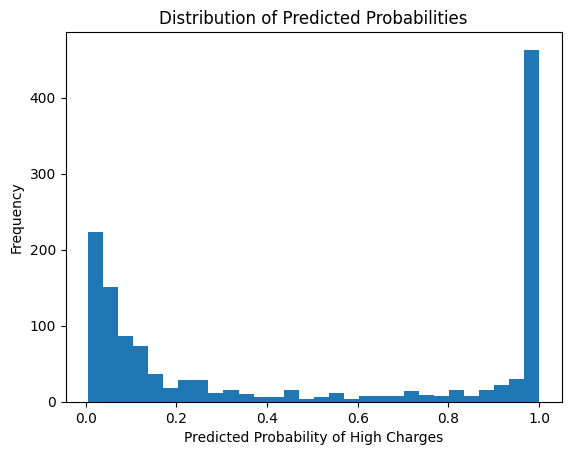

In [8]:
plt.hist(y_pred_prob, bins=30)
plt.xlabel("Predicted Probability of High Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Probabilities")
plt.show()

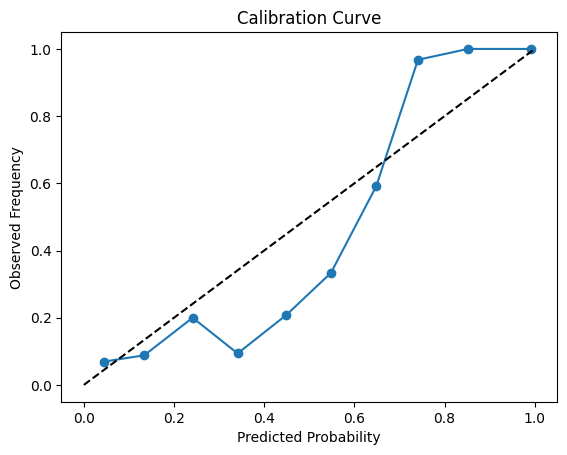

In [9]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_binary, y_pred_prob, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.show()